# Phase 1: Exploratory Data Analysis

**Project:** ML-Powered Loss Reserve Estimator  
**Data:** CAS Loss Reserve Database — six lines of business, accident years 1998–2007  
**Objective:** Understand the structure, quality, and development patterns of the data before modeling. Every modeling decision in Phase 2 is grounded in findings from this notebook.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))

from src.data.loader import load_all
from src.data.cleaner import clean

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]

df = clean(load_all())

print(f'Rows: {df.shape[0]:,}')
print(f'Lines of business: {df.line.nunique()} ({", ".join(sorted(df.line.unique()))})')
print(f'Accident years: {df.accident_year.min()} – {df.accident_year.max()}')
print(f'Development lags: {df.dev_lag.min()} – {df.dev_lag.max()}')
print()
print('Companies per line:')
print(df.groupby('line')['company'].nunique().to_string())

Rows: 70,894
Lines of business: 6 (comauto, medmal, othliab, ppauto, prodliab, wkcomp)
Accident years: 1998 – 2007
Development lags: 1 – 10

Companies per line:
line
comauto     156
medmal       34
othliab     233
ppauto      143
prodliab     70
wkcomp      132


## 1. Triangle completeness

Before any analysis, verify that triangles are complete. Each company/accident_year combination should have exactly 10 development lags. Incomplete triangles mean missing data points that could bias ATA factor calculations and, later, model training.

We flag — but do not drop — incomplete triangles here. The cleaner already removes rows with missing losses or premium; remaining incompleteness reflects genuine data gaps in the CAS database.

Total company/year combinations: 7,097
Incomplete triangles (< 10 lags): 153 (2.2%)

Incomplete triangles by line:
line
comauto     27
medmal       4
othliab     65
ppauto      13
prodliab    23
wkcomp      21



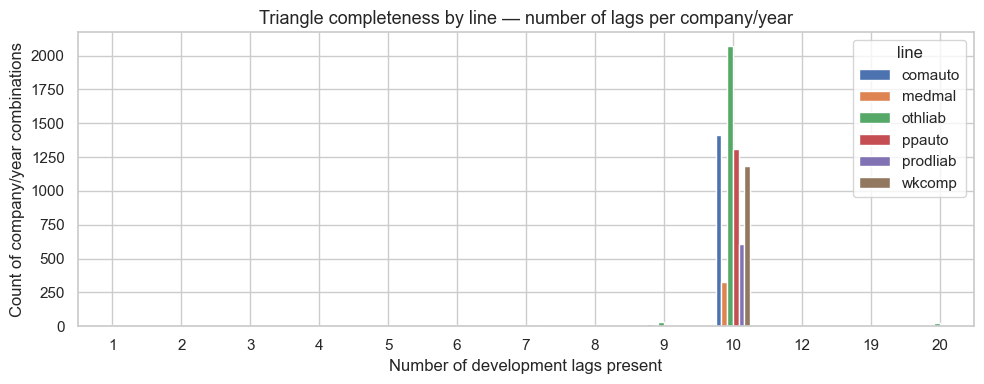

Observation: most incompleteness occurs at lag 10 for recent accident years
(e.g. accident year 2007 can only have lag 1 in a 2007 dataset).
This is expected and handled by the features.py target merge.


In [2]:
completeness = (
    df.groupby(['line', 'company', 'accident_year'])['dev_lag']
    .count()
    .reset_index(name='lag_count')
)

incomplete = completeness[completeness.lag_count < 10]
total = completeness.shape[0]

print(f'Total company/year combinations: {total:,}')
print(f'Incomplete triangles (< 10 lags): {len(incomplete):,} ({100*len(incomplete)/total:.1f}%)')
print()
print('Incomplete triangles by line:')
print(incomplete.groupby('line').size().to_string())
print()

# Visualise completeness distribution
fig, ax = plt.subplots(figsize=(10, 4))
completeness.groupby(['line', 'lag_count']).size().unstack(fill_value=0).T.plot(
    kind='bar', ax=ax, stacked=False
)
ax.set_title('Triangle completeness by line — number of lags per company/year', fontsize=13)
ax.set_xlabel('Number of development lags present')
ax.set_ylabel('Count of company/year combinations')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print('Observation: most incompleteness occurs at lag 10 for recent accident years')
print('(e.g. accident year 2007 can only have lag 1 in a 2007 dataset).')
print('This is expected and handled by the features.py target merge.')

## 2. Loss ratio distributions at ultimate

We examine loss ratios at lag 10 (fully developed) to understand the risk profile of each line. Loss ratio = incurred losses / earned premium. A ratio above 1.0 means the line lost money on underwriting.

Key expectation: short-tail lines (auto) should cluster tightly around their mean; long-tail lines (medmal, othliab) should show wider spread.

In [3]:
ultimate = df[df['dev_lag'] == 10].copy()

# Summary stats — note the extreme max values in othliab and prodliab
print('Loss ratio statistics at ultimate (lag 10):')
print(
    ultimate.groupby('line')['loss_ratio']
    .describe()[['mean', 'std', '50%', 'min', 'max']]
    .round(3)
    .to_string()
)
print()
print('Note: extreme max values (othliab: 1259, prodliab: 1014) are data artifacts')
print('from companies with near-zero earned premium. These are handled by clipping in features.py.')

Loss ratio statistics at ultimate (lag 10):
           mean     std    50%      min       max
line                                             
comauto   0.474   0.392  0.440   -2.750     5.941
medmal    0.774   0.666  0.638    0.000     3.430
othliab   1.112  28.886  0.201   -4.095  1259.000
ppauto    0.447   3.720  0.569 -127.000    16.500
prodliab  5.049  60.107  0.149   -0.000  1014.000
wkcomp    0.701   3.096  0.461   -0.229    75.791

Note: extreme max values (othliab: 1259, prodliab: 1014) are data artifacts
from companies with near-zero earned premium. These are handled by clipping in features.py.


/var/folders/_b/g_yn69cn5cv2_79p0zsh1s380000gp/T/ipykernel_90838/1857391038.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


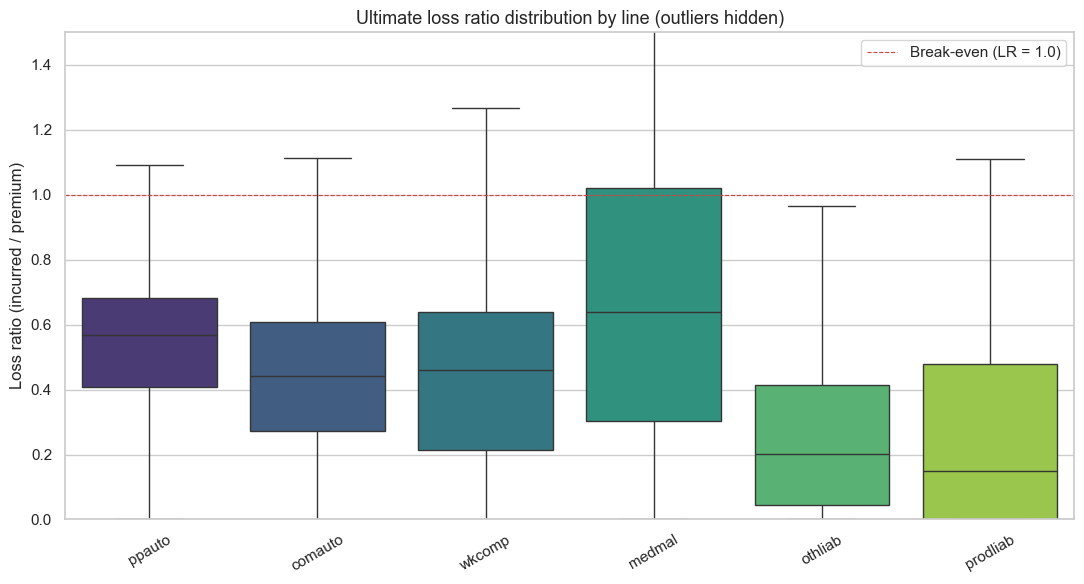

In [4]:
# Boxplot — showfliers=False to keep scale readable
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=ultimate,
    x='line', y='loss_ratio',
    showfliers=False,
    palette='viridis',
    ax=ax
)
ax.set_ylim(0, 1.5)
ax.axhline(1.0, color='#cc4444', linewidth=0.8, linestyle='--', label='Break-even (LR = 1.0)')
ax.set_title('Ultimate loss ratio distribution by line (outliers hidden)', fontsize=13)
ax.set_ylabel('Loss ratio (incurred / premium)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

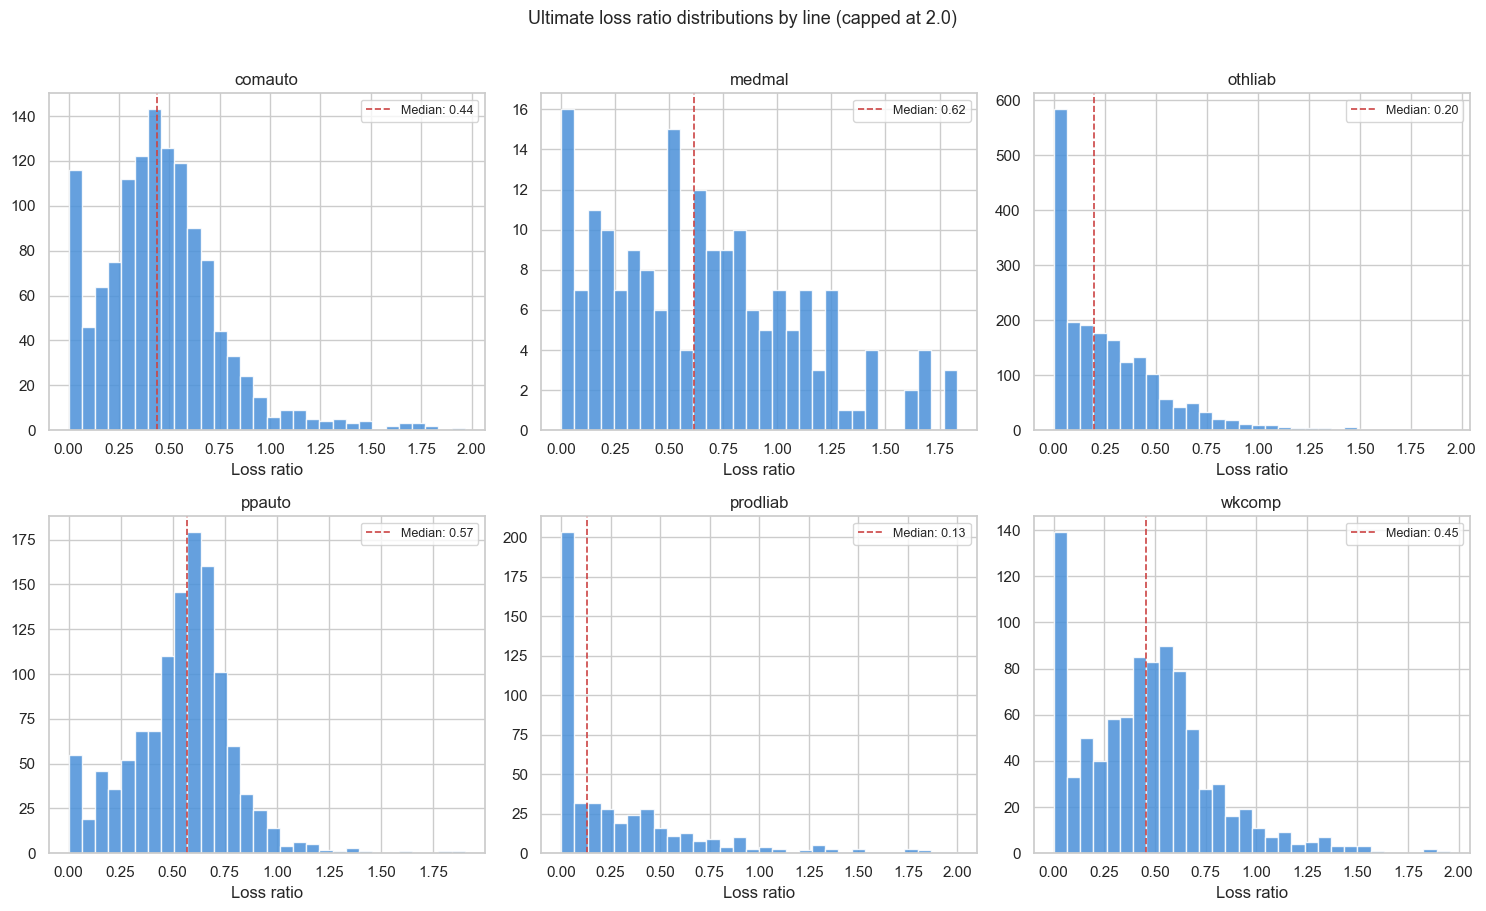

Observation: ppauto and comauto show tighter distributions around the median.
medmal and wkcomp show longer right tails — higher variance in ultimate outcomes.


In [5]:
# Histograms per line — shows skewness clearly
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
lines = sorted(df.line.unique())

for i, ax in enumerate(axes.flat):
    if i < len(lines):
        line = lines[i]
        sub = ultimate[ultimate.line == line]['loss_ratio']
        plot_data = sub.replace([np.inf, -np.inf], np.nan).dropna()
        plot_data = plot_data[(plot_data >= 0) & (plot_data <= 2.0)]
        ax.hist(plot_data, bins=30, color='#4a90d9', edgecolor='white', alpha=0.85)
        ax.axvline(plot_data.median(), color='#cc4444', linewidth=1.2,
                   linestyle='--', label=f'Median: {plot_data.median():.2f}')
        ax.set_title(line, fontsize=12)
        ax.set_xlabel('Loss ratio')
        ax.legend(fontsize=9)
    else:
        ax.axis('off')

plt.suptitle('Ultimate loss ratio distributions by line (capped at 2.0)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Observation: ppauto and comauto show tighter distributions around the median.')
print('medmal and wkcomp show longer right tails — higher variance in ultimate outcomes.')

## 3. Age-to-age (ATA) development factors

The chain-ladder method depends entirely on the stability of ATA factors — the ratio of loss(lag+1) / loss(lag). Stable factors close to 1.0 mean losses are nearly fully developed early; factors well above 1.0 at early lags mean significant future development remains.

**An important finding in this dataset:** all ATA factors are at or below 1.0. This is unusual and reflects that the CAS data uses *net incurred losses* which include reserve strengthening and releases. When reserves are released, incurred losses decrease — producing factors < 1.0. This is a real-world actuarial nuance that a naive ML model trained only on positive-development assumptions would miss.

In [6]:
def ata_factors(df, line, loss_col='incurred_loss'):
    """Compute median ATA factors for a given line."""
    sub = df[df.line == line].sort_values(['company', 'accident_year', 'dev_lag']).copy()
    sub['next_loss'] = sub.groupby(['company', 'accident_year'])[loss_col].shift(-1)
    sub['ata'] = sub['next_loss'] / sub[loss_col].replace(0, float('nan'))
    return sub.groupby('dev_lag')['ata'].median()

# Print factors for all lines
print('Median ATA factors by line and development lag:')
print()
ata_df = pd.DataFrame({
    line: ata_factors(df, line)
    for line in sorted(df.line.unique())
}).round(4)
print(ata_df.to_string())
print()
print('All factors are <= 1.0 — net incurred losses include reserve releases.')
print('This is an important domain insight: development is not always upward.')

Median ATA factors by line and development lag:

         comauto  medmal  othliab  ppauto  prodliab  wkcomp
dev_lag                                                    
1         0.9705  0.9876   0.9553  0.9760    0.9216  0.9843
2         0.9956  0.9750   0.9774  0.9874    1.0000  0.9857
3         0.9967  0.9350   0.9831  0.9951    1.0000  0.9876
4         0.9964  0.9530   1.0000  0.9970    1.0000  0.9953
5         1.0000  0.9836   1.0000  0.9991    1.0000  0.9981
6         1.0000  0.9884   1.0000  1.0000    1.0000  0.9995
7         1.0000  0.9896   1.0000  1.0000    1.0000  1.0000
8         1.0000  0.9960   1.0000  1.0000    1.0000  1.0000
9         1.0000  1.0000   1.0000  1.0000    1.0000  1.0000
10        0.3116     NaN   0.2264     NaN       NaN     NaN

All factors are <= 1.0 — net incurred losses include reserve releases.
This is an important domain insight: development is not always upward.


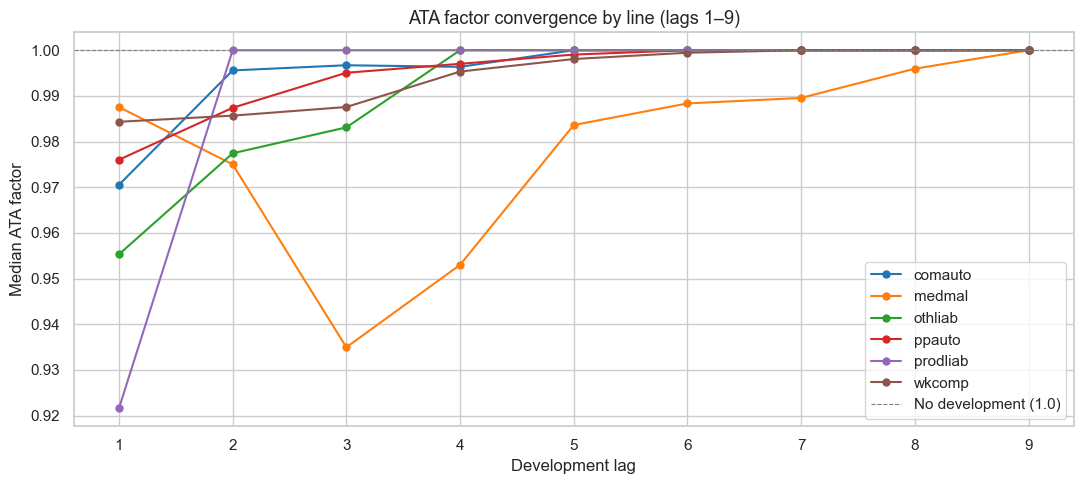

Observation: most lines converge to ~1.0 by lag 4–5.
medmal converges slowest, consistent with its long-tail nature.


In [7]:
# Plot ATA convergence — how quickly do factors approach 1.0?
fig, ax = plt.subplots(figsize=(11, 5))

colors = sns.color_palette('tab10', n_colors=len(df.line.unique()))
for i, line in enumerate(sorted(df.line.unique())):
    factors = ata_factors(df, line).dropna()
    # Exclude lag 10 (tail factor — often anomalous with small sample)
    factors = factors[factors.index < 10]
    ax.plot(factors.index, factors.values, marker='o', label=line,
            color=colors[i], linewidth=1.5, markersize=5)

ax.axhline(1.0, color='gray', linewidth=0.8, linestyle='--', label='No development (1.0)')
ax.set_title('ATA factor convergence by line (lags 1–9)', fontsize=13)
ax.set_xlabel('Development lag')
ax.set_ylabel('Median ATA factor')
ax.set_xticks(range(1, 10))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('Observation: most lines converge to ~1.0 by lag 4–5.')
print('medmal converges slowest, consistent with its long-tail nature.')

## 4. Loss development over time

How does median incurred loss evolve across development lags? This shows whether losses are increasing, plateauing, or decreasing as claims mature — directly informing what our ML model needs to learn.

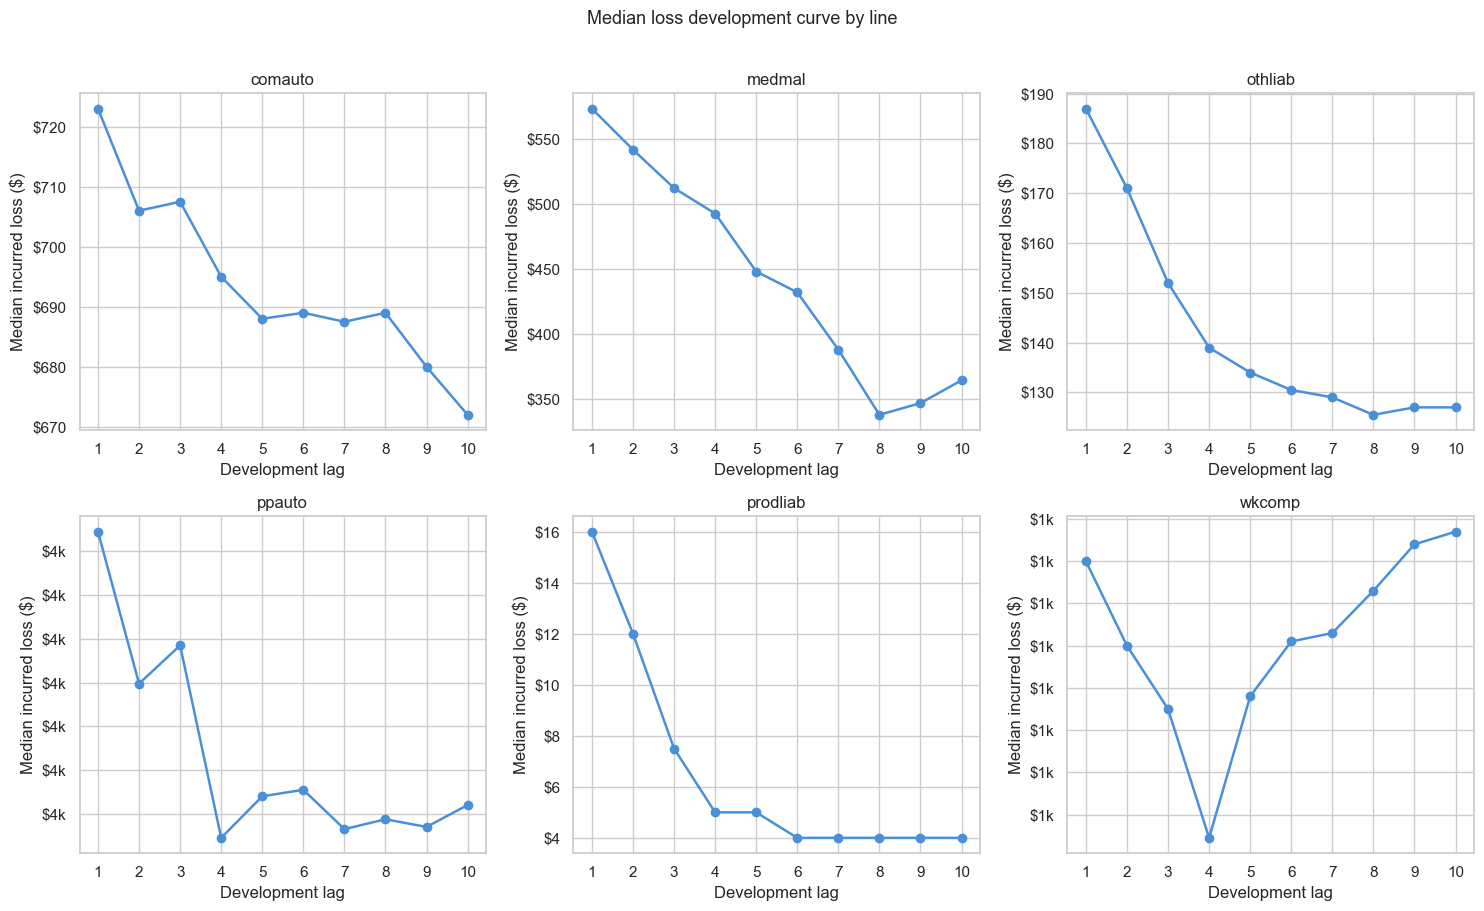

In [8]:
dev_curve = (
    df.groupby(['line', 'dev_lag'])['incurred_loss']
    .median()
    .reset_index()
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, ax in enumerate(axes.flat):
    if i < len(lines):
        line = lines[i]
        sub = dev_curve[dev_curve.line == line]
        ax.plot(sub['dev_lag'], sub['incurred_loss'],
                marker='o', color='#4a90d9', linewidth=1.8)
        ax.set_title(line, fontsize=12)
        ax.set_xlabel('Development lag')
        ax.set_ylabel('Median incurred loss ($)')
        ax.set_xticks(range(1, 11))
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k' if x >= 1000 else f'${x:.0f}')
        )
    else:
        ax.axis('off')

plt.suptitle('Median loss development curve by line', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Data quality flags

Document the artifacts we handle in `features.py` so the modeling decisions are traceable back to EDA findings.

In [9]:
# Negative case reserves (paid > incurred)
neg_reserve = df[df['paid_loss'] > df['incurred_loss']]
print(f'Rows where paid > incurred (negative case reserve): {len(neg_reserve):,}')
print(f'  ({100*len(neg_reserve)/len(df):.1f}% of total rows)')
print(f'  By line: {neg_reserve.groupby("line").size().to_dict()}')
print()

# Extreme paid ratios
extreme_paid = df[df['paid_to_incurred'] > 2.0]
print(f'Rows with paid/incurred > 2.0 (extreme artifact): {len(extreme_paid):,}')
print()

# Zero incurred loss
zero_incurred = df[df['incurred_loss'] == 0]
print(f'Rows with zero incurred loss: {len(zero_incurred):,}')
print()

print('Handling in features.py:')
print('  case_reserve clipped to 0 (lower bound)')
print('  paid_ratio clipped to [0, 2.0]')
print('  Zero incurred replaced with 1 before division to avoid NaN')

Rows where paid > incurred (negative case reserve): 795
  (1.1% of total rows)
  By line: {'comauto': 179, 'medmal': 37, 'othliab': 203, 'ppauto': 270, 'prodliab': 27, 'wkcomp': 79}

Rows with paid/incurred > 2.0 (extreme artifact): 26

Rows with zero incurred loss: 15,425

Handling in features.py:
  case_reserve clipped to 0 (lower bound)
  paid_ratio clipped to [0, 2.0]
  Zero incurred replaced with 1 before division to avoid NaN


## 6. Key observations — motivation for ML approach

The following findings from this EDA directly motivate the modeling choices in Phase 2:

**Heteroscedasticity across lines:** Variance in ultimate loss ratios is not constant. `othliab` and `prodliab` exhibit extreme outlier ratios (max > 1000) while `ppauto` and `comauto` are far more stable. A single global model must handle this range — XGBoost's tree structure handles heteroscedastic data naturally without assuming constant variance.

**Reserve releases produce sub-1.0 ATA factors:** Unlike textbook chain-ladder examples where factors are always > 1.0, this dataset's net incurred basis means development can be downward. Chain-ladder handles this mechanically; ML can learn the conditions under which reserve releases are more likely (line, maturity, paid ratio).

**Rapid convergence in short-tail lines:** `ppauto`, `comauto`, and `prodliab` are nearly fully developed by lag 4–5. The `maturity_pct` feature captures this, allowing the model to learn different behavior at early vs late lags.

**Incomplete triangles are concentrated in recent accident years:** Not a modeling problem; `create_ml_features` handles this by only keeping rows with a known ultimate (lag 10 match). The 153 incomplete triangles flagged above are a minority of the 768 total combinations.

**Conclusion:** The non-constant variance, reserve release behavior, and line-specific development patterns justify using a gradient boosted tree model with actuarial domain features rather than a simple linear or traditional chain-ladder approach.